# The objective of this code is to generate neuronal networks where neurons don't have a probability 1 to connect within a given radius but have a probability p. 
### Also if possibly not uniformly distributed

# Nothing done yet in this notebook, only a copy from P1

### 1. Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

### 2. Setting up the network

### Random network in a 1x1 square

Original number of nodes: 10000
Original number of edges: 15267
Giant component nodes: 155
Giant component edges: 292
GC fraction: 0.0155


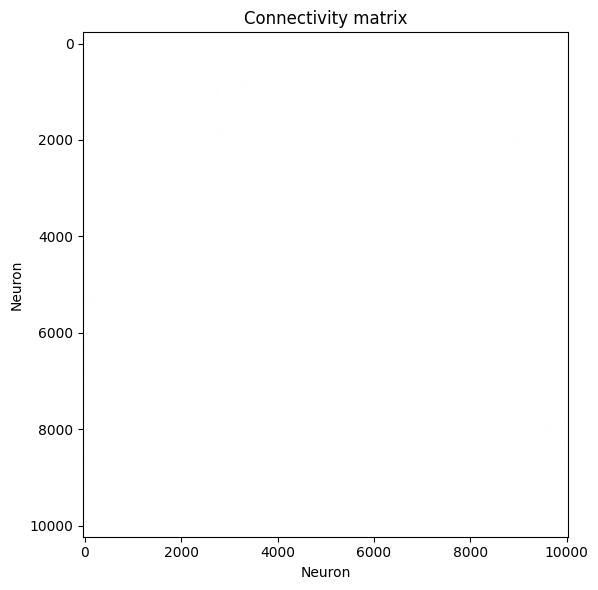

In [2]:
# setting up the graph

NT = 10000  # Number of total neurons



radius = 0.01

network = nx.random_geometric_graph(NT, radius)  # Random geometric graph with radius 0.1


# =========================
# Original adjacency matrix
# =========================

A = nx.to_numpy_array(network)
np.fill_diagonal(A, 0)

# =========================
# Giant component network
# =========================

giant_nodes = max(nx.connected_components(network), key=len)

B_network = network.subgraph(giant_nodes).copy()

# Relabel nodes from 0 to N_gc-1
B_network = nx.convert_node_labels_to_integers(B_network)

# Adjacency matrix of the giant component
B = nx.to_numpy_array(B_network)
np.fill_diagonal(B, 0)

print("Original number of nodes:", network.number_of_nodes())
print("Original number of edges:", network.number_of_edges())
print("Giant component nodes:", B_network.number_of_nodes())
print("Giant component edges:", B_network.number_of_edges())
print("GC fraction:", B_network.number_of_nodes() / NT)



# =========================
# Connectivity matrix
# =========================

NT = B.shape[0]  # Number of neurons in the giant component
Ne = int(NT*0.8)  # N of excitatory neurons
Ni = NT - Ne  # N of inhibitory neurons



MAX_EXC_WEIGHT = 8
MAX_INH_WEIGHT = 0.5

W = np.hstack([
    MAX_EXC_WEIGHT * np.random.rand(NT, Ne),
    -MAX_INH_WEIGHT * np.random.rand(NT, Ni)
])

S = B * W

plt.figure(figsize=(6, 6))
plt.imshow(A, cmap="binary", origin="upper")
plt.xlabel("Neuron")
plt.ylabel("Neuron")
plt.title("Connectivity matrix")
plt.axis("equal")
plt.tight_layout()
plt.show()

Número de neuronas: 2000
Número de enlaces: 92294
Grado medio: 92.294
Densidad: 0.046170085042521264
La red no es conexa
Tamaño de la componente gigante: 1997
Fracción en componente gigante: 0.9985


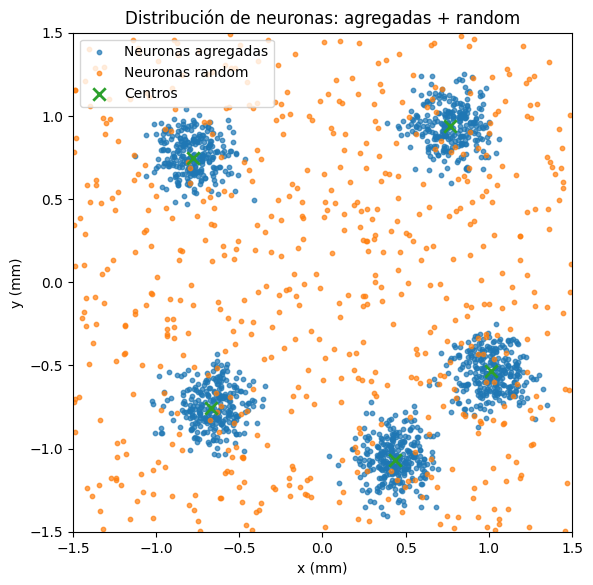

In [9]:
# Poner neuronas en un plano de LxL
## Poner un 70% agragadas y el otro 30% random
## La agregación la hacemos poniendo unos centros de menra aleatoria en la red con una cierta anchura y 
## colocando las neuronas en esos centros, el resto random en el espacio.
# Generar conexiones de acuerdo a la distancia entre neuronas con una cierta probabilidad de conexión.

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx


# ============================================================
# Parámetros principales
# ============================================================

L = 3.0                 # Tamaño del dominio L x L, en mm
N = 2000                # Número total de neuronas

frac_agg = 0.70         # Fracción de neuronas agregadas
n_centers = 5          # Número de centros de agregación
base_sigma = 0.12       # Anchura de los agregados, en mm

r_conn = 0.3         # Radio de conexión, en mm
alpha = 0.5           # Probabilidad de conexión si están dentro del radio

seed = 123
rng = np.random.default_rng(seed)


# ============================================================
# Generar posiciones: 70% agregadas + 30% random
# ============================================================

def generate_mixed_positions(
    N,
    L,
    frac_agg=0.7,
    n_centers=20,
    base_sigma=0.12,
    rng=None
):
    """
    Genera posiciones 2D en un dominio cuadrado [-L/2, L/2] x [-L/2, L/2].

    Un porcentaje frac_agg de neuronas se coloca alrededor de centros
    gaussianos, y el resto se coloca aleatoriamente de forma uniforme.
    """

    if rng is None:
        rng = np.random.default_rng()

    N_agg = int(frac_agg * N)
    N_rand = N - N_agg

    # ------------------------------------------------------------
    # Centros de agregación
    # ------------------------------------------------------------

    # Para evitar centros demasiado pegados al borde
    margin = 2.5 * base_sigma

    centers = rng.uniform(
        low=-L/2 + margin,
        high=L/2 - margin,
        size=(n_centers, 2)
    )

    # ------------------------------------------------------------
    # Neuronas agregadas
    # ------------------------------------------------------------

    agg_positions = []

    while len(agg_positions) < N_agg:

        # Elegir un centro al azar
        c = centers[rng.integers(0, n_centers)]

        # Generar una posición gaussiana alrededor del centro
        pos = rng.normal(loc=c, scale=base_sigma, size=2)

        # Aceptar solo si cae dentro del dominio
        if -L/2 <= pos[0] <= L/2 and -L/2 <= pos[1] <= L/2:
            agg_positions.append(pos)

    agg_positions = np.array(agg_positions)

    # ------------------------------------------------------------
    # Neuronas random uniformes
    # ------------------------------------------------------------

    rand_positions = rng.uniform(
        low=-L/2,
        high=L/2,
        size=(N_rand, 2)
    )

    # ------------------------------------------------------------
    # Juntar posiciones
    # ------------------------------------------------------------

    positions = np.vstack([agg_positions, rand_positions])

    # Etiqueta para saber cuáles son agregadas y cuáles random
    labels = np.array(
        ["agg"] * N_agg + ["rand"] * N_rand
    )

    return positions, centers, labels


positions, centers, labels = generate_mixed_positions(
    N=N,
    L=L,
    frac_agg=frac_agg,
    n_centers=n_centers,
    base_sigma=base_sigma,
    rng=rng
)


# ============================================================
# Crear matriz de adyacencia según distancia y probabilidad alpha
# ============================================================

def create_distance_network(
    positions,
    r_conn,
    alpha=0.2,
    directed=False,
    rng=None
):
    """
    Crea una matriz de adyacencia A.

    Si la distancia entre dos neuronas es menor que r_conn,
    se conectan con probabilidad alpha.

    directed=False crea una red no dirigida.
    directed=True crea una red dirigida.
    """

    if rng is None:
        rng = np.random.default_rng()

    N = positions.shape[0]
    A = np.zeros((N, N), dtype=int)

    if directed:

        for i in range(N):
            for j in range(N):

                if i == j:
                    continue

                dist = np.linalg.norm(positions[i] - positions[j])

                if dist <= r_conn:
                    if rng.random() < alpha:
                        A[i, j] = 1

    else:

        for i in range(N):
            for j in range(i + 1, N):

                dist = np.linalg.norm(positions[i] - positions[j])

                if dist <= r_conn:
                    if rng.random() < alpha:
                        A[i, j] = 1
                        A[j, i] = 1

    return A


A = create_distance_network(
    positions=positions,
    r_conn=r_conn,
    alpha=alpha,
    directed=False,
    rng=rng
)


# ============================================================
# Convertir a grafo de NetworkX
# ============================================================

G = nx.from_numpy_array(A)

print("Número de neuronas:", N)
print("Número de enlaces:", G.number_of_edges())
print("Grado medio:", np.mean([d for _, d in G.degree()]))
print("Densidad:", nx.density(G))

if nx.is_connected(G):
    print("La red es conexa")
else:
    GC = max(nx.connected_components(G), key=len)
    print("La red no es conexa")
    print("Tamaño de la componente gigante:", len(GC))
    print("Fracción en componente gigante:", len(GC) / N)


# ============================================================
# Plot de posiciones
# ============================================================

fig, ax = plt.subplots(figsize=(6, 6))

mask_agg = labels == "agg"
mask_rand = labels == "rand"

ax.scatter(
    positions[mask_agg, 0],
    positions[mask_agg, 1],
    s=10,
    alpha=0.7,
    label="Neuronas agregadas"
)

ax.scatter(
    positions[mask_rand, 0],
    positions[mask_rand, 1],
    s=10,
    alpha=0.7,
    label="Neuronas random"
)

ax.scatter(
    centers[:, 0],
    centers[:, 1],
    s=80,
    marker="x",
    linewidths=2,
    label="Centros"
)

ax.set_xlim(-L/2, L/2)
ax.set_ylim(-L/2, L/2)
ax.set_aspect("equal")

ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.set_title("Distribución de neuronas: agregadas + random")
ax.legend()

plt.tight_layout()
plt.show()

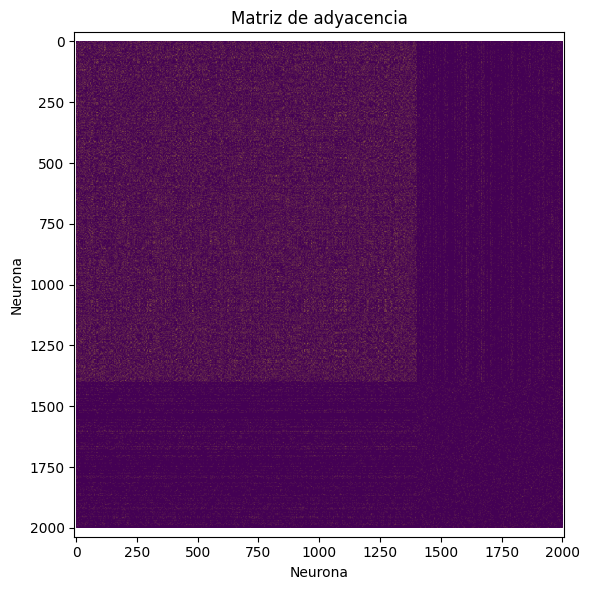

In [10]:
# Plot Adj

plt.figure(figsize=(6, 6))
plt.imshow(A, cmap="viridis", origin="upper")
plt.xlabel("Neurona")
plt.ylabel("Neurona")
plt.title("Matriz de adyacencia")
plt.axis("equal")
plt.tight_layout()
plt.show()

### Random network in a LxL square

Original number of nodes: 5000
Original number of edges: 34535
Giant component nodes: 5000
Giant component edges: 34535
GC fraction: 1.0


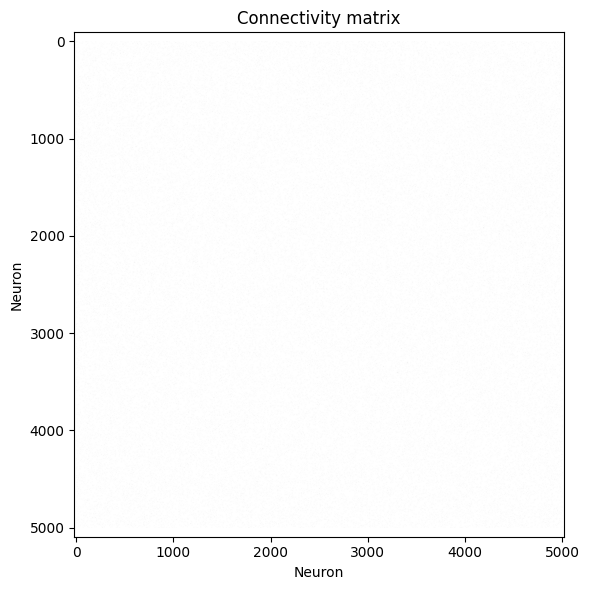

In [3]:
# setting up the graph

NT = 5000  # Number of total neurons

radius = 0.3

L = 10

# Positions in [0, L] x [0, L]
pos = {
    i: L * np.random.rand(2)
    for i in range(NT)
}


network = nx.random_geometric_graph(NT, radius, pos=pos)  # Random geometric graph with radius 0.1


# =========================
# Original adjacency matrix
# =========================

A = nx.to_numpy_array(network)
np.fill_diagonal(A, 0)

# =========================
# Giant component network
# =========================

giant_nodes = max(nx.connected_components(network), key=len)

B_network = network.subgraph(giant_nodes).copy()

# Relabel nodes from 0 to N_gc-1
B_network = nx.convert_node_labels_to_integers(B_network)

# Adjacency matrix of the giant component
B = nx.to_numpy_array(B_network)
np.fill_diagonal(B, 0)

print("Original number of nodes:", network.number_of_nodes())
print("Original number of edges:", network.number_of_edges())
print("Giant component nodes:", B_network.number_of_nodes())
print("Giant component edges:", B_network.number_of_edges())
print("GC fraction:", B_network.number_of_nodes() / NT)



# =========================
# Connectivity matrix
# =========================

NT = B.shape[0]  # Number of neurons in the giant component
Ne = int(NT*0.8)  # N of excitatory neurons
Ni = NT - Ne  # N of inhibitory neurons



MAX_EXC_WEIGHT = 8
MAX_INH_WEIGHT = 0.5

W = np.hstack([
    MAX_EXC_WEIGHT * np.random.rand(NT, Ne),
    -MAX_INH_WEIGHT * np.random.rand(NT, Ni)
])

S = B * W

plt.figure(figsize=(6, 6))
plt.imshow(A, cmap="binary", origin="upper")
plt.xlabel("Neuron")
plt.ylabel("Neuron")
plt.title("Connectivity matrix")
plt.axis("equal")
plt.tight_layout()
plt.show()

In [4]:

# MAX_EXC_WEIGHT = 15
# MAX_INH_WEIGHT = 0.5

# W = np.hstack([
#     MAX_EXC_WEIGHT * np.random.rand(NT, Ne),
#     -MAX_INH_WEIGHT * np.random.rand(NT, Ni)
# ])

# S = B * W


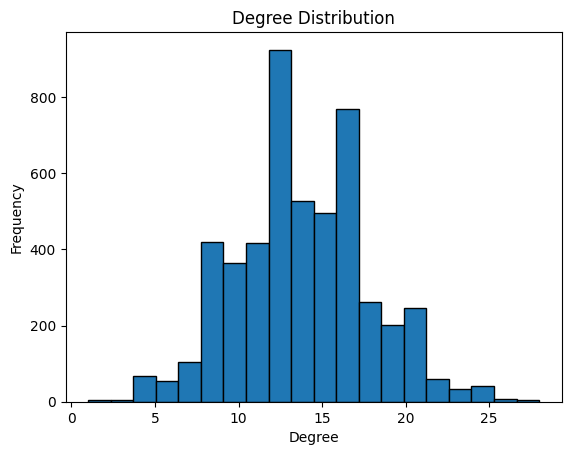

In [5]:
# Plot the degree distribution of the giant component network
degrees = [degree for node, degree in B_network.degree()]
plt.hist(degrees, bins=20, edgecolor="black")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.title("Degree Distribution")
plt.show()

# Network distribution

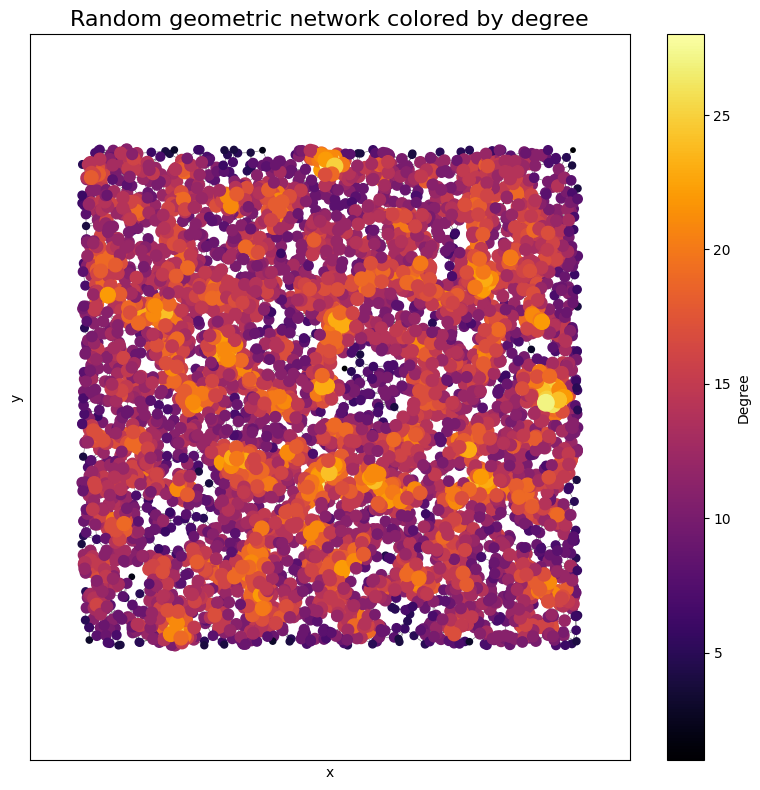

In [6]:
pos = nx.get_node_attributes(network, "pos")

degrees = dict(network.degree())
degree_values = np.array([degrees[i] for i in network.nodes()])

node_sizes = 5 + 5 * degree_values

plt.figure(figsize=(8, 8))

nx.draw_networkx_edges(
    network,
    pos,
    edge_color="black",
    alpha=0.6,
    width=0.4
)

nodes = nx.draw_networkx_nodes(
    network,
    pos,
    node_size=node_sizes,
    node_color=degree_values,
    cmap="inferno",
    alpha=1
)

plt.colorbar(nodes, label="Degree")

plt.title("Random geometric network colored by degree", fontsize=16)
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.tight_layout()
plt.show()

## 3. Base matrix to check tests

In [49]:
def generate_mixed_positions(
    N,
    L,
    frac_agg,
    n_centers,
    base_sigma,
    rng,
    sigma_mode="same",
    sigma_min=0.05,
    sigma_max=0.20
):
    """
    Genera posiciones en un dominio cuadrado L x L.

    sigma_mode:
        "same"   -> todos los centros tienen sigma = base_sigma
        "random" -> cada centro tiene una sigma aleatoria entre sigma_min y sigma_max
    """

    N_agg = int(frac_agg * N)
    N_rand = N - N_agg

    # ============================================================
    # Centros de agregación
    # ============================================================

    centers = rng.uniform(
        low=-L/2,
        high=L/2,
        size=(n_centers, 2)
    )

    # ============================================================
    # Sigma de cada centro
    # ============================================================

    if sigma_mode == "same":
        sigmas = np.full(n_centers, base_sigma)

    elif sigma_mode == "random":
        sigmas = rng.uniform(
            low=sigma_min,
            high=sigma_max,
            size=n_centers
        )

    else:
        raise ValueError("sigma_mode debe ser 'same' o 'random'")

    # ============================================================
    # Neuronas agregadas
    # ============================================================

    positions_agg = []

    for i in range(N_agg):
        # Elegimos un centro al azar
        c_idx = rng.integers(0, n_centers)

        center = centers[c_idx]
        sigma = sigmas[c_idx]

        # Generamos una neurona alrededor de ese centro
        pos = rng.normal(
            loc=center,
            scale=sigma,
            size=2
        )

        # Si cae fuera del dominio, la reintentamos
        while (
            pos[0] < -L/2 or pos[0] > L/2 or
            pos[1] < -L/2 or pos[1] > L/2
        ):
            pos = rng.normal(
                loc=center,
                scale=sigma,
                size=2
            )

        positions_agg.append(pos)

    positions_agg = np.array(positions_agg)

    # ============================================================
    # Neuronas random
    # ============================================================

    positions_rand = rng.uniform(
        low=-L/2,
        high=L/2,
        size=(N_rand, 2)
    )

    # ============================================================
    # Juntar posiciones
    # ============================================================

    positions = np.vstack([positions_agg, positions_rand])

    labels = np.array(["agg"] * N_agg + ["rand"] * N_rand)

    return positions, centers, labels, sigmas



def create_distance_network(
    positions,
    r_conn,
    alpha=0.2,
    directed=False,
    rng=None
):
    """
    Crea una matriz de adyacencia A.

    Si la distancia entre dos neuronas es menor que r_conn,
    se conectan con probabilidad alpha.

    directed=False crea una red no dirigida.
    directed=True crea una red dirigida.
    """

    if rng is None:
        rng = np.random.default_rng()

    N = positions.shape[0]
    A = np.zeros((N, N), dtype=int)

    if directed:

        for i in range(N):
            for j in range(N):

                if i == j:
                    continue

                dist = np.linalg.norm(positions[i] - positions[j])

                if dist <= r_conn:
                    if rng.random() < alpha:
                        A[i, j] = 1

    else:

        for i in range(N):
            for j in range(i + 1, N):

                dist = np.linalg.norm(positions[i] - positions[j])

                if dist <= r_conn:
                    if rng.random() < alpha:
                        A[i, j] = 1
                        A[j, i] = 1

    return A

Número de neuronas: 2000
Número de enlaces: 99620
Grado medio: 99.62
Densidad: 0.049834917458729366
La red no es conexa
Tamaño de la componente gigante: 1366
Fracción en componente gigante: 0.683
Número de comunidades detectadas: 41
Tamaños de comunidades: [364, 216, 199, 197, 193, 192, 181, 181, 176, 35, 6, 6, 5, 5, 4, 4, 3, 3, 3, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


C:\Users\Admin\AppData\Local\Temp\ipykernel_2044\1259187847.py:152: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False)


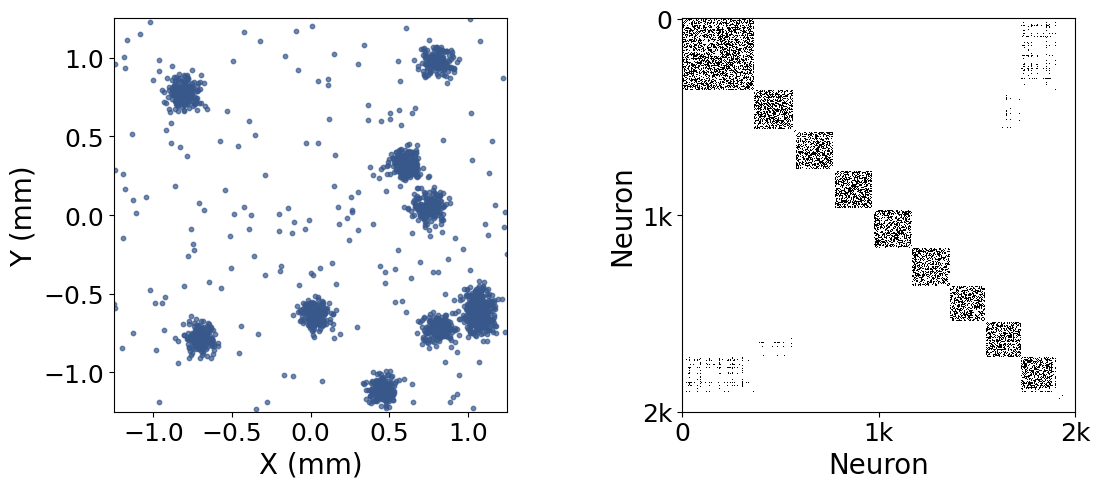

In [65]:
# Poner neuronas en un plano de LxL
## Poner un 70% agragadas y el otro 30% random
## La agregación la hacemos poniendo unos centros de menra aleatoria en la red con una cierta anchura y 
## colocando las neuronas en esos centros, el resto random en el espacio.
# Generar conexiones de acuerdo a la distancia entre neuronas con una cierta probabilidad de conexión.

import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from pypalettes import load_cmap

viridis = load_cmap("viridis")


# ============================================================
# Parámetros principales
# ============================================================

L = 2.5                 # Tamaño del dominio L x L, en mm
N = 2000                # Número total de neuronas

frac_agg = 0.9  # Fracción de neuronas agregadas
n_centers = 10        # Número de centros de agregación
base_sigma = 0.05       # Anchura de los agregados, en mm

r_conn = 0.2         # Radio de conexión, en mm
alpha = 0.5           # Probabilidad de conexión si están dentro del radio

seed = 123
rng = np.random.default_rng(seed)


# ============================================================
# Generar posiciones: 70% agregadas + 30% random
# ============================================================

positions, centers, labels, sigmas = generate_mixed_positions(
    N=N,
    L=L,
    frac_agg=frac_agg,
    n_centers=n_centers,
    base_sigma=base_sigma,
    rng=rng,
    sigma_mode="same",   # "same" o "random"
    sigma_min=0.05,
    sigma_max=0.20
)

# ============================================================
# Crear matriz de adyacencia según distancia y probabilidad alpha
# ============================================================

A = create_distance_network(
    positions=positions,
    r_conn=r_conn,
    alpha=alpha,
    directed=False,
    rng=rng
)

# ============================================================
# Convertir a grafo de NetworkX
# ============================================================

G = nx.from_numpy_array(A)

print("Número de neuronas:", N)
print("Número de enlaces:", G.number_of_edges())
print("Grado medio:", np.mean([d for _, d in G.degree()]))
print("Densidad:", nx.density(G))

if nx.is_connected(G):
    print("La red es conexa")
else:
    GC = max(nx.connected_components(G), key=len)
    print("La red no es conexa")
    print("Tamaño de la componente gigante:", len(GC))
    print("Fracción en componente gigante:", len(GC) / N)


# ============================================================
# Ordenar matriz de adyacencia por comunidades
# ============================================================

# Detectar comunidades con Louvain
communities = nx.community.louvain_communities(G, seed=seed)

# Ordenar comunidades por tamaño, de mayor a menor
communities = sorted(communities, key=len, reverse=True)

# Lista de nodos ordenados por comunidad
ordered_nodes = []
community_boundaries = []

count = 0
for comm in communities:
    comm_sorted = sorted(list(comm))
    ordered_nodes.extend(comm_sorted)

    count += len(comm_sorted)
    community_boundaries.append(count)

# Reordenar matriz de adyacencia
A_ordered = A[np.ix_(ordered_nodes, ordered_nodes)]

print("Número de comunidades detectadas:", len(communities))
print("Tamaños de comunidades:", [len(c) for c in communities])


# ============================================================
# Plot conjunto: posiciones + matriz de adyacencia ordenada
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(12, 5),
    gridspec_kw={"width_ratios": [1, 1]}
)

# ============================================================
# Izquierda: distribución espacial
# ============================================================

ax = axes[0]

mask_agg = labels == "agg"
mask_rand = labels == "rand"

ax.scatter(
    positions[mask_agg, 0],
    positions[mask_agg, 1],
    s=10,
    alpha=0.7,
    color=viridis(0.2)
)

ax.scatter(
    positions[mask_rand, 0],
    positions[mask_rand, 1],
    s=10,
    alpha=0.7,
    color=viridis(0.2)
)

ax.set_xlim(-L/2, L/2)
ax.set_ylim(-L/2, L/2)
ax.set_aspect("equal")

ax.set_xlabel("X (mm)", fontsize = 20)
ax.set_ylabel("Y (mm)", fontsize = 20)
# ax.set_title("Distribución de neuronas")
ax.legend(frameon=False)
ax.tick_params(labelsize=18)


# ============================================================
# Derecha: matriz de adyacencia ordenada por comunidades
# ============================================================

ax = axes[1]

im = ax.imshow(
    A_ordered,
    cmap="Greys",
    interpolation="nearest",
    origin="upper"
)

# ax.set_title("Matriz de adyacencia ordenada por comunidades")
ax.set_xlabel("Neuron", fontsize = 20)
ax.set_ylabel("Neuron", fontsize = 20)
ax.tick_params(labelsize=18)
ax.set_xticks([0, 1000, 2000])
ax.set_xticklabels(["0", "1k", "2k"])
ax.set_yticks([0, 1000, 2000])
ax.set_yticklabels(["0", "1k", "2k"])

# Dibujar líneas separando comunidades
# for boundary in community_boundaries[:-1]:
#     ax.axhline(boundary - 0.5, color="red", linewidth=0.8, alpha=0.7)
#     ax.axvline(boundary - 0.5, color="red", linewidth=0.8, alpha=0.7)

plt.tight_layout()
plt.show()

## 4. Simulating the neurons

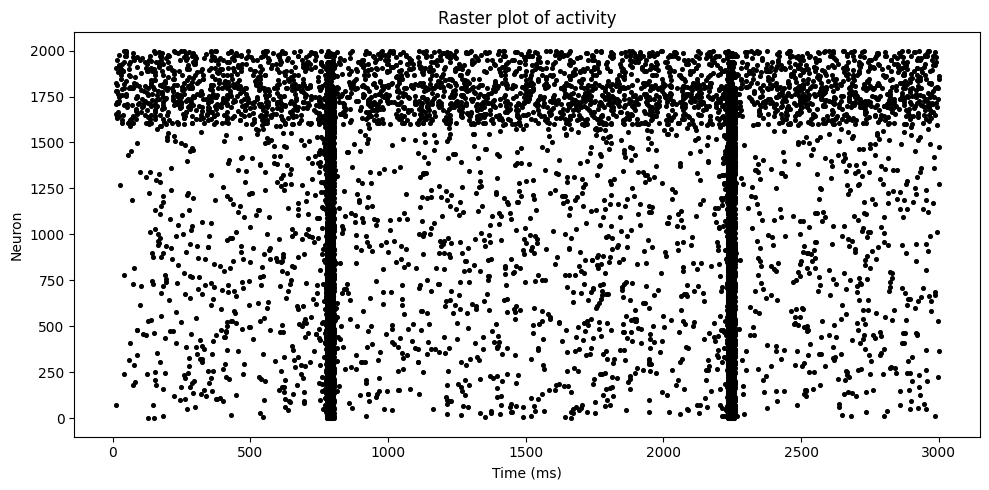

In [70]:

## Simulations

SIM_TIME = 3000
MAX_EXC_WEIGHT = 3.5
MAX_INH_WEIGHT = 0.5

W = np.hstack([
    MAX_EXC_WEIGHT * np.random.rand(N, Ne),
    -MAX_INH_WEIGHT * np.random.rand(N, Ni)
])

S = A * W
 
# Reproducibilidad opcional
np.random.seed(42)

# =========================
# Izhikevich parameters
# =========================

re = np.random.rand(Ne)
ri = np.random.rand(Ni)

a = np.concatenate([
    0.02 * np.ones(Ne),
    0.02 + 0.08 * ri
])

b = np.concatenate([
    0.2 * np.ones(Ne),
    0.25 - 0.05 * ri
])

c = np.concatenate([
    -65 + 15 * re**2,
    -65 * np.ones(Ni)
])

d = np.concatenate([
    8 - 6 * re**2,
    2 * np.ones(Ni)
])

# =========================
# MAIN SIMULATION
# =========================

NOISE_MAX = 3

v = -65 * np.ones(N)
u = b * v

firings = []

for t in range(1, SIM_TIME + 1):

    I = np.concatenate([
        NOISE_MAX * np.random.randn(Ne),
        2 * np.random.randn(Ni)
    ])

    fired = np.where(v >= 30)[0]

    if len(fired) > 0:
        firings.extend([(t, neuron) for neuron in fired])

        v[fired] = c[fired]
        u[fired] += d[fired]

        I += np.sum(S[:, fired], axis=1)

    v += 0.5 * (0.04 * v**2 + 5 * v + 140 - u + I)
    v += 0.5 * (0.04 * v**2 + 5 * v + 140 - u + I)
    u += a * (b * v - u)

firings = np.array(firings)

# =========================
# Raster plot
# =========================

plt.figure(figsize=(10, 5))

plt.scatter(
    firings[:, 0],
    firings[:, 1],
    s=7,
    color="black"
)

plt.xlabel("Time (ms)")
plt.ylabel("Neuron")
plt.title("Raster plot of activity")
plt.tight_layout()
plt.show()

# Plotting 

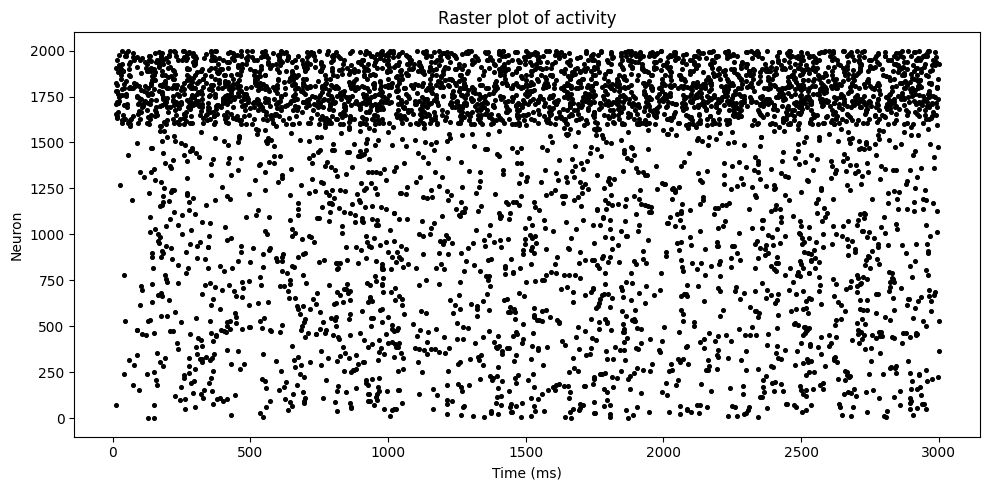

In [38]:
# =========================
# Raster plot
# =========================

plt.figure(figsize=(10, 5))

plt.scatter(
    firings[:, 0],
    firings[:, 1],
    s=7,
    color="black"
)

plt.xlabel("Time (ms)")
plt.ylabel("Neuron")
plt.title("Raster plot of activity")
plt.tight_layout()
plt.show()

In [11]:
# =========================
# SYNC measure
# =========================

WINDOW = 20
SIM_TIME_SYNC = 3000

n_windows = SIM_TIME_SYNC // WINDOW
num_active = np.zeros(n_windows)

for j in range(n_windows):
    t_min = WINDOW * j
    t_max = WINDOW * (j + 1)

    mask = (firings[:, 0] > t_min) & (firings[:, 0] <= t_max)
    neurons = firings[mask, 1]

    num_active[j] = len(np.unique(neurons)) / NT

sync = np.max(num_active)

print("Sync =", sync)
print("Active fraction per window:")
print(num_active)

Sync = 0.0204
Active fraction per window:
[0.0074 0.0156 0.0132 0.0114 0.014  0.016  0.0144 0.0186 0.0138 0.0142
 0.0134 0.0186 0.0144 0.0142 0.0152 0.013  0.014  0.02   0.0194 0.0168
 0.0164 0.0188 0.0168 0.0148 0.0156 0.017  0.0128 0.0176 0.0144 0.014
 0.0164 0.0132 0.0186 0.0122 0.0144 0.0186 0.0104 0.0182 0.017  0.0154
 0.0154 0.0138 0.0178 0.0176 0.0168 0.0158 0.015  0.0204 0.0184 0.0164
 0.0168 0.0122 0.0138 0.0148 0.0142 0.0162 0.0166 0.0168 0.0138 0.016
 0.0176 0.0154 0.0164 0.0142 0.0136 0.017  0.0168 0.0162 0.0182 0.018
 0.0184 0.0152 0.0142 0.0178 0.0184 0.014  0.016  0.0136 0.0116 0.0174
 0.011  0.0142 0.0126 0.0146 0.0166 0.0136 0.0148 0.0166 0.018  0.0156
 0.0172 0.0152 0.0148 0.0144 0.0154 0.0154 0.016  0.0136 0.0164 0.0148
 0.012  0.0192 0.0168 0.0176 0.0132 0.0168 0.0188 0.0146 0.016  0.0146
 0.0158 0.0182 0.0184 0.0162 0.0132 0.0148 0.0172 0.0148 0.018  0.0128
 0.0132 0.014  0.0144 0.0168 0.0176 0.014  0.0144 0.0142 0.0176 0.0164
 0.018  0.0164 0.0144 0.0166 0.019  0.

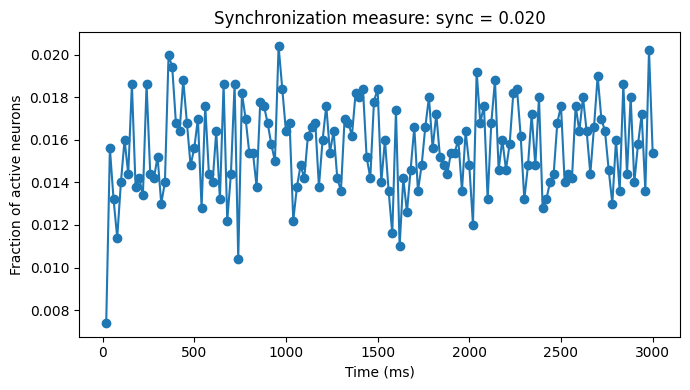

In [12]:
plt.figure(figsize=(7, 4))

times = np.arange(1, n_windows + 1) * WINDOW

plt.plot(times, num_active, marker="o")
plt.xlabel("Time (ms)")
plt.ylabel("Fraction of active neurons")
plt.title(f"Synchronization measure: sync = {sync:.3f}")
plt.tight_layout()
plt.show()